In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# 自动定位项目根目录：notebook 位于 notes/ 下，向上一级即为项目根
cwd = os.getcwd()
if os.path.basename(cwd) == 'notes':
    os.chdir('..')
print('当前工作目录:', os.getcwd())

当前工作目录: d:\github\prediction


In [8]:
# ============================================================
# 方法一: 基线模型 —— 每小时历史均值预测（后续修改代码，这个代码块锁定不许动！）
# ============================================================
# 从预处理好的 CSV 加载训练集和测试集 (已包含 pm_ave / TEMP / HUMI)
df_train = pd.read_csv('data/df_train.csv', index_col='datetime', parse_dates=True)
df_test  = pd.read_csv('data/df_test.csv',  index_col='datetime', parse_dates=True)

# 基线预测: 用训练集每小时历史均值作为预测值
hourly_baseline = df_train.groupby(df_train.index.hour)['pm_ave'].mean()
df_prediction = pd.DataFrame({
    'timestamp': df_test.index,
    'predicted_pm_ave': df_test.index.hour.map(hourly_baseline)
})

# 把真实值并进 df_prediction (按行对齐，两者时间戳顺序一致)
df_prediction['actual_pm_ave'] = df_test['pm_ave'].values

# 逐条比对: 残差 = 真实值 - 预测值 (每个测试点单独算，不先做小时平均)
df_prediction['error'] = df_prediction['actual_pm_ave'] - df_prediction['predicted_pm_ave']

# 只保留有真实值的点参与 loss (三站全缺失的测试点无法评估)
mask = df_prediction['actual_pm_ave'].notna()
err = df_prediction.loc[mask, 'error']

# 均方误差 MSE = 残差平方的均值
mse = (err ** 2).mean()

print(f'有效比对样本数: {mask.sum()} / {len(df_prediction)}')
print(f'MSE = {mse:.2f}')
df_prediction.head(300)

有效比对样本数: 401 / 401
MSE = 5477.94


,timestamp,predicted_pm_ave,actual_pm_ave,error
0,2015-12-15 07:00:00,55.532867,271.333333,215.800466
1,2015-12-15 08:00:00,56.999767,261.000000,204.000233
2,2015-12-15 09:00:00,56.732380,250.333333,193.600954
3,2015-12-15 10:00:00,55.710901,234.333333,178.622432
4,2015-12-15 11:00:00,54.634949,201.333333,146.698385
...,...,...,...,...
295,2015-12-27 14:00:00,53.070396,41.000000,-12.070396
296,2015-12-27 15:00:00,53.451964,38.333333,-15.118630
297,2015-12-27 16:00:00,53.110179,40.000000,-13.110179
298,2015-12-27 17:00:00,53.695102,41.666667,-12.028435


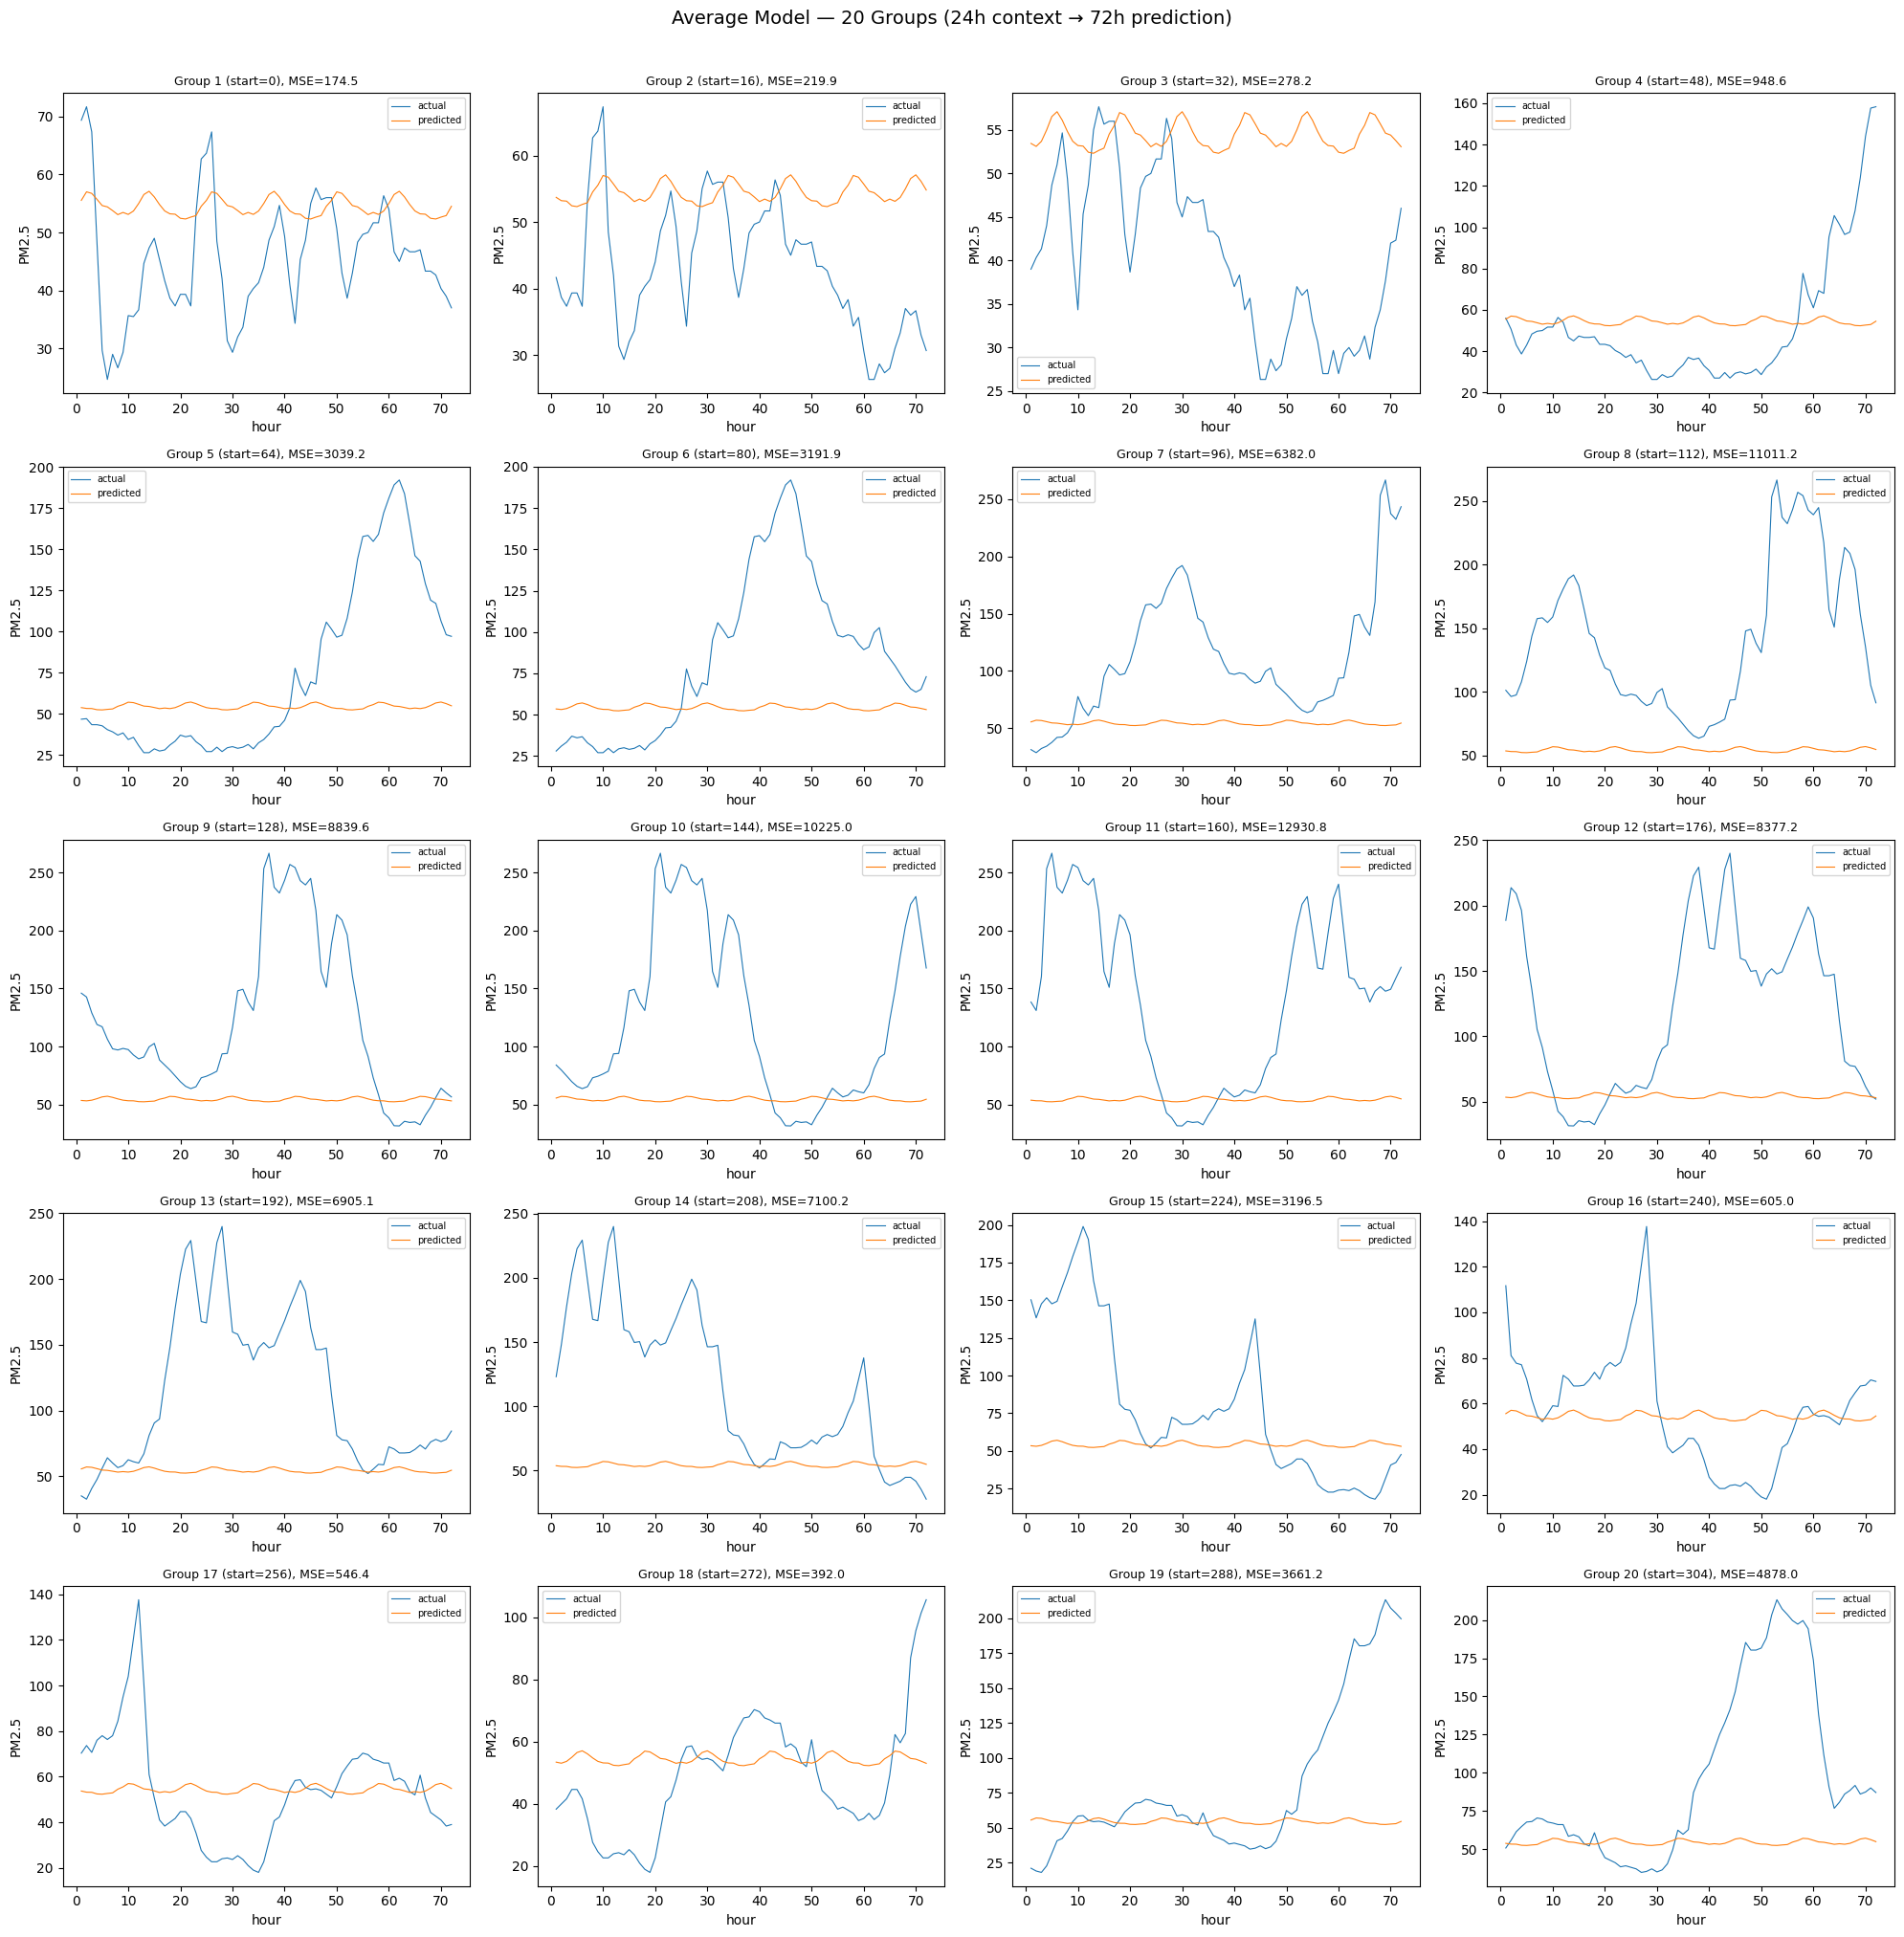


=== 20 组 MSE 汇总 ===
  Group  1: MSE = 174.47
  Group  2: MSE = 219.93
  Group  3: MSE = 278.17
  Group  4: MSE = 948.57
  Group  5: MSE = 3039.21
  Group  6: MSE = 3191.89
  Group  7: MSE = 6381.97
  Group  8: MSE = 11011.20
  Group  9: MSE = 8839.63
  Group 10: MSE = 10224.96
  Group 11: MSE = 12930.79
  Group 12: MSE = 8377.15
  Group 13: MSE = 6905.10
  Group 14: MSE = 7100.24
  Group 15: MSE = 3196.46
  Group 16: MSE = 605.02
  Group 17: MSE = 546.45
  Group 18: MSE = 392.03
  Group 19: MSE = 3661.17
  Group 20: MSE = 4877.96

平均 MSE = 4645.12


In [9]:
# ============================================================
# 20 组评估: 每组 24h 上下文 + 72h 预测 (基线模型)
# 基线模型直接用每小时历史均值, 无需多步预测
# ============================================================
import numpy as np

N_GROUPS = 20
N_CONTEXT = 24
N_PREDICT = 72
STRIDE = (len(df_test) - N_CONTEXT - N_PREDICT) // (N_GROUPS - 1)

pm_test = df_test['pm_ave'].values

all_mses = []
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for g in range(N_GROUPS):
    start = g * STRIDE
    ctx_end = start + N_CONTEXT
    pred_end = ctx_end + N_PREDICT

    # 基线预测: 直接查表 hourly_baseline
    pred_hours = df_test.index[ctx_end:pred_end].hour
    preds = pred_hours.map(hourly_baseline).values
    actual = pm_test[ctx_end:pred_end]

    mse = ((preds - actual) ** 2).mean()
    all_mses.append(mse)

    ax = axes[g]
    hours = np.arange(1, N_PREDICT + 1)
    ax.plot(hours, actual, linewidth=0.8, label='actual')
    ax.plot(hours, preds, linewidth=0.8, label='predicted')
    ax.set_title(f'Group {g+1} (start={start}), MSE={mse:.1f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('hour')
    ax.set_ylabel('PM2.5')

plt.suptitle('Average Model — 20 Groups (24h context → 72h prediction)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\n=== 20 组 MSE 汇总 ===')
for g, mse in enumerate(all_mses):
    print(f'  Group {g+1:2d}: MSE = {mse:.2f}')
print(f'\n平均 MSE = {np.mean(all_mses):.2f}')